___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# Tensorflow Project Exercise
Let's wrap up this Deep Learning by taking a a quick look at the effectiveness of Neural Nets!

We'll use the [Bank Authentication Data Set](https://archive.ics.uci.edu/ml/datasets/banknote+authentication) from the UCI repository.

The data consists of 5 columns:

* variance of Wavelet Transformed image (continuous)
* skewness of Wavelet Transformed image (continuous)
* curtosis of Wavelet Transformed image (continuous)
* entropy of image (continuous)
* class (integer)

Where class indicates whether or not a Bank Note was authentic.

This sort of task is perfectly suited for Neural Networks and Deep Learning! Just follow the instructions below to get started!

## Get the Data

** Use pandas to read in the bank_note_data.csv file **

In [50]:
import pandas as pd

In [51]:
df=pd.read_csv('bank_note_data.csv')

** Check the head of the Data **

In [52]:
df.head()

,Image.Var,Image.Skew,Image.Curt,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## EDA

We'll just do a few quick plots of the data.

** Import seaborn and set matplolib inline for viewing **

In [53]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

** Create a Countplot of the Classes (Authentic 1 vs Fake 0) **

<Axes: xlabel='Class', ylabel='count'>

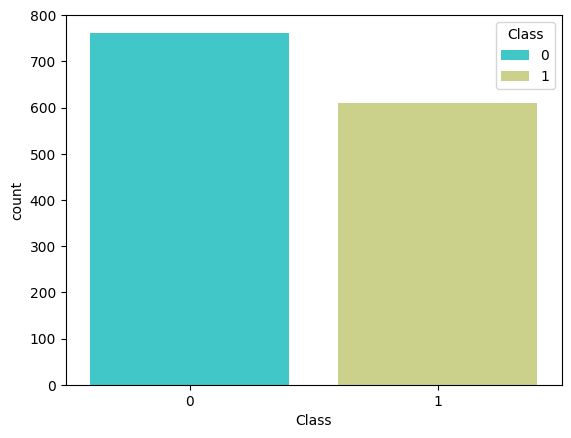

In [54]:
sns.countplot(df,x='Class',palette='rainbow',hue='Class')

** Create a PairPlot of the Data with Seaborn, set Hue to Class **

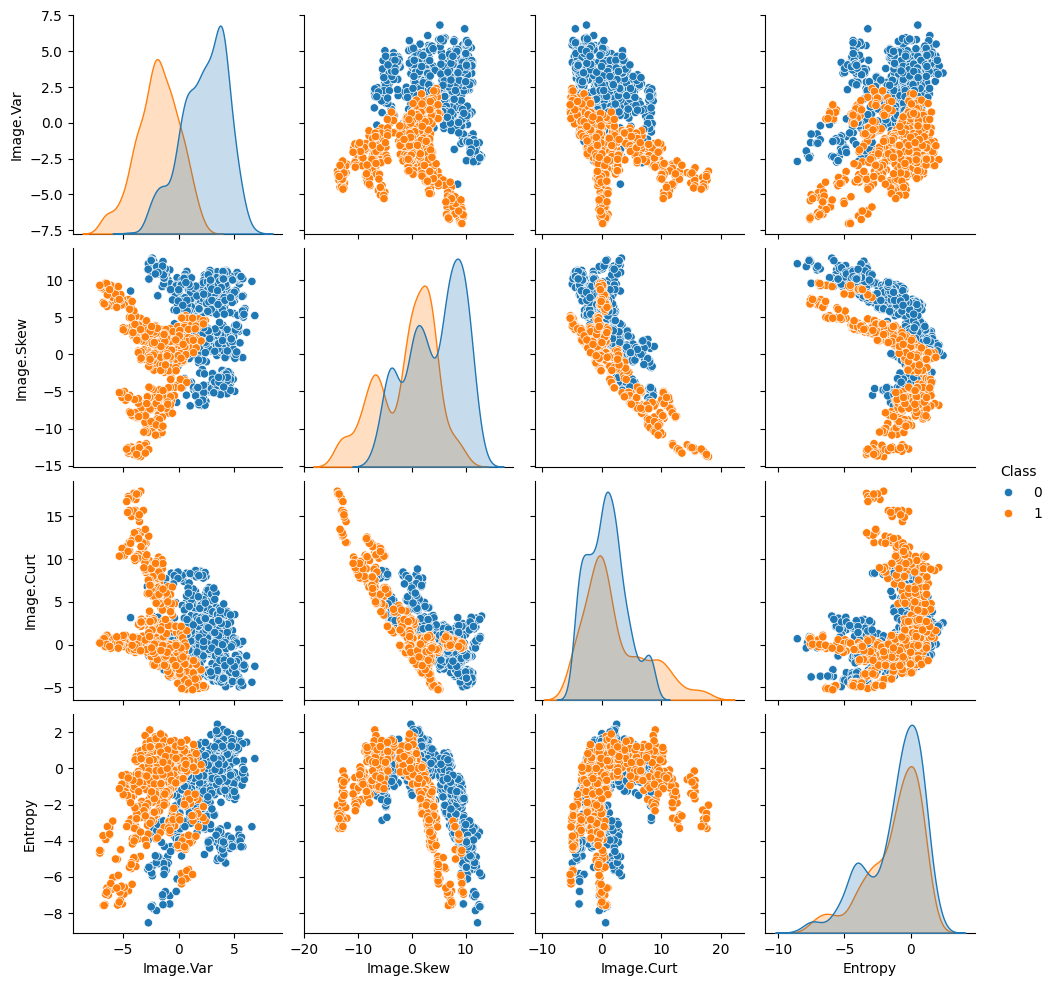

In [55]:
sns.pairplot(df,hue='Class')

## Data Preparation 

When using Neural Network and Deep Learning based systems, it is usually a good idea to Standardize your data, this step isn't actually necessary for our particular data set, but let's run through it for practice!

### Standard Scaling



In [56]:
from sklearn.preprocessing import StandardScaler

**Create a StandardScaler() object called scaler.**

In [57]:
scaler = StandardScaler()

**Fit scaler to the features.**

In [58]:
scaler.fit(df.drop('Class',axis=1))

,copy,True
,with_mean,True
,with_std,True


**Use the .transform() method to transform the features to a scaled version.**

In [59]:
scaled_features = scaler.transform(df.drop('Class', axis=1))


**Convert the scaled features to a dataframe and check the head of this dataframe to make sure the scaling worked.**

In [60]:
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df_feat.head()

,Image.Var,Image.Skew,Image.Curt,Entropy
0,1.121806,1.149455,-0.975970,0.354561
1,1.447066,1.064453,-0.895036,-0.128767
2,1.207810,-0.777352,0.122218,0.618073
3,1.063742,1.295478,-1.255397,-1.144029
4,-0.036772,-1.087038,0.736730,0.096587


## Train Test Split

** Create two objects X and y which are the scaled feature values and labels respectively.**

In [61]:
X = df_feat
y = df['Class']

In [62]:
X

,Image.Var,Image.Skew,Image.Curt,Entropy
0,1.121806,1.149455,-0.975970,0.354561
1,1.447066,1.064453,-0.895036,-0.128767
2,1.207810,-0.777352,0.122218,0.618073
3,1.063742,1.295478,-1.255397,-1.144029
4,-0.036772,-1.087038,0.736730,0.096587
...,...,...,...,...
1367,-0.009711,-0.097693,-0.660962,0.300996
1368,-0.641313,-1.158984,1.179023,0.730127
1369,-1.472357,-2.621646,3.759017,-0.754884
1370,-1.406693,-1.756471,2.552043,-0.043158


** Use SciKit Learn to create training and testing sets of the data as we've done in previous lectures:**

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [65]:
X_train.shape

(960, 4)

In [66]:
X_train.head()

,Image.Var,Image.Skew,Image.Curt,Entropy
77,-0.135326,0.719518,0.089399,0.224034
1072,-0.633325,-0.296271,-0.114249,1.319967
50,1.368944,-1.160041,0.473017,0.292373
122,-0.665418,1.227060,0.080046,-1.872372
930,-0.934339,-0.368223,-0.194396,0.594062


# Tensorflow

In [67]:
import tensorflow as tf

** Create a list of feature column objects using tf.feature.numeric_column() as we did in the lecture**

In [68]:
feat_col=[]
for col in X.columns:
    feat_col.append(tf.feature_column.numeric_column(col))

In [69]:
feat_col

[NumericColumn(key='Image.Var', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None),
 NumericColumn(key='Image.Skew', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None),
 NumericColumn(key='Image.Curt', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None),
 NumericColumn(key='Entropy', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)]

In [70]:
len(feat_col)

4

** Create an object called classifier which is a DNNClassifier from learn. Set it to have 2 classes and a [10,20,10] hidden unit layer structure:**

In [71]:
import tensorflow_estimator as tfe

In [72]:
classifier = tf.estimator.DNNClassifier(
    hidden_units=[10,20,10],
    n_classes=2,
    feature_columns=feat_col
)

INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\JHONWI~1\\AppData\\Local\\Temp\\tmp8si10fex', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


** Now create a tf.estimator.pandas_input_fn that takes in your X_train, y_train, batch_size and set shuffle=True. You can play around with the batch_size parameter if you want, but let's start by setting it to 20 since our data isn't very big. **

In [73]:
input_func = tf.compat.v1.estimator.inputs.pandas_input_fn(
    x=X_train,
    y=y_train,
    batch_size=20,
    num_epochs=None,
    shuffle=True
)

In [74]:
classifier.train(input_fn=input_func, steps=500)

INFO:tensorflow:Calling model_fn.


INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Create CheckpointSaverHook.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.
INFO:tensorflow:Calling checkpoint listeners before saving checkpoint 0...
INFO:tensorflow:Saving checkpoints for 0 into C:\Users\JHONWI~1\AppData\Local\Temp\tmp8si10fex\model.ckpt.
INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 0...
INFO:tensorflow:loss = 0.6568223, step = 0
INFO:tensorflow:global_step/sec: 162.687
INFO:tensorflow:loss = 0.6410641, step = 100 (0.621 sec)
INFO:tensorflow:global_step/sec: 169.352
INFO:tensorflow:loss = 0.6633404, step = 200 (0.589 sec)
INFO:tensorflow:global_step/sec: 185.748
INFO:tensorflow:loss = 0.5874228, step = 300 (0.547 sec)
INFO:tensorflow:global_step/sec: 173.794
INFO:tensorflow:loss = 0.55212003, step = 400 (0.567 sec)
INFO:tensorflow:Calling checkpoint listeners before saving checkpoint 500...
INFO:tensorflow:Saving check

## Model Evaluation

** Create another pandas_input_fn that takes in the X_test data for x. Remember this one won't need any y_test info since we will be using this for the network to create its own predictions. Set shuffle=False since we don't need to shuffle for predictions.**

In [75]:
pred_fn = tf.compat.v1.estimator.inputs.pandas_input_fn(
    x=X_test,
    batch_size=len(X_test),
    shuffle=False
)

** Use the predict method from the classifier model to create predictions from X_test **

In [76]:
predictions =list(classifier.predict(input_fn=pred_fn))

INFO:tensorflow:Calling model_fn.


INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\JHONWI~1\AppData\Local\Temp\tmp8si10fex\model.ckpt-500
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.


In [77]:
predictions

[{'logits': array([0.5568709], dtype=float32),
  'logistic': array([0.63572824], dtype=float32),
  'probabilities': array([0.36427176, 0.63572824], dtype=float32),
  'class_ids': array([1], dtype=int64),
  'classes': array([b'1'], dtype=object),
  'all_class_ids': array([0, 1]),
  'all_classes': array([b'0', b'1'], dtype=object)},
 {'logits': array([-0.7089909], dtype=float32),
  'logistic': array([0.32982188], dtype=float32),
  'probabilities': array([0.6701782 , 0.32982188], dtype=float32),
  'class_ids': array([0], dtype=int64),
  'classes': array([b'0'], dtype=object),
  'all_class_ids': array([0, 1]),
  'all_classes': array([b'0', b'1'], dtype=object)},
 {'logits': array([0.34494504], dtype=float32),
  'logistic': array([0.5853912], dtype=float32),
  'probabilities': array([0.41460875, 0.5853912 ], dtype=float32),
  'class_ids': array([1], dtype=int64),
  'classes': array([b'1'], dtype=object),
  'all_class_ids': array([0, 1]),
  'all_classes': array([b'0', b'1'], dtype=object)},


In [78]:
final_preds = []
for pred in predictions:
    final_preds.append(pred['class_ids'][0])

** Now create a classification report and a Confusion Matrix. Does anything stand out to you?**

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

In [80]:
print(confusion_matrix(y_test, final_preds))

[[161  77]
 [ 28 146]]


In [81]:
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.85      0.68      0.75       238
           1       0.65      0.84      0.74       174

    accuracy                           0.75       412
   macro avg       0.75      0.76      0.74       412
weighted avg       0.77      0.75      0.75       412



## Optional Comparison

** You should have noticed extremely accurate results from the DNN model. Let's compare this to a Random Forest Classifier for a reality check!**

**Use SciKit Learn to Create a Random Forest Classifier and compare the confusion matrix and classification report to the DNN model**

In [82]:
from sklearn.ensemble import RandomForestClassifier

In [83]:
rfc = RandomForestClassifier(n_estimators=200)

In [84]:
rfc.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [85]:
rfc_preds = rfc.predict(X_test)

In [86]:
print(confusion_matrix(y_test, rfc_preds))

[[234   4]
 [  0 174]]


In [87]:
print(classification_report(y_test, rfc_preds))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



** It should have also done very well, possibly perfect! Hopefully you have seen the power of DNN! **

# Great Job!